In [1]:
import sys
import os
sys.path.append(os.path.abspath("../clean_code/"))

In [2]:
from Visualization import generalVisualization
from Visualization import gloveVisuals
from Visualization import visualHelpers
from Utilities import config

import pickle
import select_landmarks_MI
import importlib
import voltagemap
import setofpoints
import main
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.datasets import fetch_openml

In [3]:
importlib.reload(generalVisualization)
importlib.reload(gloveVisuals)
importlib.reload(visualHelpers)
importlib.reload(voltagemap)
importlib.reload(main)

<module 'main' from '/home/avighna/Documents/python/VoltageDimentionalReduction/clean_code/main.py'>

In [7]:
config.params['file_path']= '../../Voltage_Data/glove/shuffled_output.txt'
config.params['split_char']= ' '
config.params['normalize_vecs'] = True

config.params['max_centroids']= 1000
config.params['init_size']= 5000
config.params['batch_size']= 1000
config.params['kmeans_output']= '../../Voltage_Temp/Results/glove.npy'
config.params['k']=2
config.params['r']=1

data_to_save = main.main()

Read 5000 vectors
Estimated max pairwise distance squared, FAISS) = 2.9098
 Estimated minimum distance squared = 0.0000
10 vectors in index after adding initial centroid
Read 6000 vectors
number of centroids: 540, max_centroids: 1000
Read 7000 vectors
number of centroids: 975, max_centroids: 1000
Read 8000 vectors
number of centroids: 1000, max_centroids: 1000
Reached maximum number of centroids: 1000
Read 34000 vectorsmean d2= 0.8370783946422432
no of parts= 1


ParseException: ['']

In [8]:
import kagglehub

path = kagglehub.dataset_download("thanakomsn/glove6b300dtxt")

print(path)

/home/avighna/.cache/kagglehub/datasets/thanakomsn/glove6b300dtxt/versions/1


In [9]:
def load_glove_vectors(filepath, max_words=100000):
    word2vec = {}
    with open(filepath, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i >= max_words:
                break
            parts = line.strip().split()
            word = parts[0]
            vector = list(map(float, parts[1:]))
            word2vec[word] = vector
    return word2vec

# Example
glove_path = path + "/glove.6B.300d.txt"  # or 300d
glove_vectors = load_glove_vectors(glove_path, max_words=1000)

In [14]:
words = list(glove_vectors.keys())
vectors = [glove_vectors[word] for word in words]
data = setofpoints.SetOfPoints(np.array(vectors))

In [16]:
all_voltages = main.compute_voltages(data)

<class 'setofpoints.SetOfPoints'>


In [17]:
voltage_map = select_landmarks_MI.select_landmarks(all_voltages)

Adding landmark index=0 lm_index=2 with MI=1.1412
Adding landmark index=2 lm_index=143 with MI=2.0558
Adding landmark index=3 lm_index=376 with MI=2.8429
Adding landmark index=5 lm_index=151 with MI=3.5332
Adding landmark index=4 lm_index=1 with MI=4.1178
Adding landmark index=7 lm_index=34 with MI=4.6231
Adding landmark index=8 lm_index=215 with MI=5.0653
Adding landmark index=7 lm_index=150 with MI=5.5394
Adding landmark index=20 lm_index=76 with MI=5.7409
Adding landmark index=10 lm_index=853 with MI=5.8862


In [21]:
data_to_save = {"all_voltages": all_voltages, "voltage_map": voltage_map, "centroids": data}

In [22]:
with open('../../Voltage_Temp/Results/glove_voltage_map.npy', 'wb') as f:
    pickle.dump(data_to_save, f)

In [23]:
with open('../../Voltage_Temp/Results/glove_voltage_map.npy', 'rb') as f:
    data_to_save = pickle.load(f)

In [40]:
voltage_map = voltagemap.VoltageMap()
for entry in data_to_save['voltage_map'].entries:
    voltage_map.add_solution(entry["landmark"], np.log(entry["voltages"]))

In [43]:
def plot_text(transformed_points, words, voltages, ax, image_size, landmarkSize, alpha_actual, remove_clutter):
    landmark_indicies = [landmark.index for landmark in voltages.get_all_landmarks()]
    drawn_xy = []
    size_sqrd = image_size ** 2
    for i in range(transformed_points.shape[0]):
        landmark = i in landmark_indicies
        color = 'white'
        fontsize = 8
        
        if landmark:
            color = 'yellow'
            fontsize *= landmarkSize
            
        x, y = transformed_points[i]

        draw = True

        if remove_clutter:
            for (x2, y2) in drawn_xy:
                if ((x2 - x) ** 2 + (y2 - y) ** 2 < size_sqrd):
                    draw = False
                    break

        if draw:
            if remove_clutter:
                drawn_xy.append((x, y))

            ax.text(transformed_points[i, 0], transformed_points[i, 1], str(words[i]),
                    color=color, fontsize=fontsize, alpha=alpha_actual,
                    ha='center', va='center')


In [44]:
def plot_voltage_words(voltages, words, transformation="mds", landmarkSize=3, alpha_actual=1, percent_size=0.02, remove_clutter=True, out_file=None):
    """
    Visualizes voltage-based word embeddings in 2D using MDS or PCA.
    Each word is plotted as text at its transformed position.

    Args:
        voltages: VoltageMap object containing the voltage embedding.
        words: List of strings to display.
        transformation: Dimensionality reduction method ('mds' or 'pca').
        landmarkSize: Size of landmark points.
        alpha_actual: Transparency of the text.
        percent_size: Controls image size scaling.
        remove_clutter: (Unused, for compatibility).
        out_file: If given, saves figure to file.
    """
    points = voltages.voltage_array()
    transformed_points = visualHelpers.transform(points, transformation)
    x_bound, y_bound, image_size = visualHelpers.compute_image_size(transformed_points, percent_size)
    fig, ax = visualHelpers.setup_figure(x_bound, y_bound, image_size, landmarkSize, "Voltage Map Words")

    plot_text(transformed_points, words, voltages, ax, image_size, landmarkSize, alpha_actual, remove_clutter)

    visualHelpers.standard_save_display(out_file)

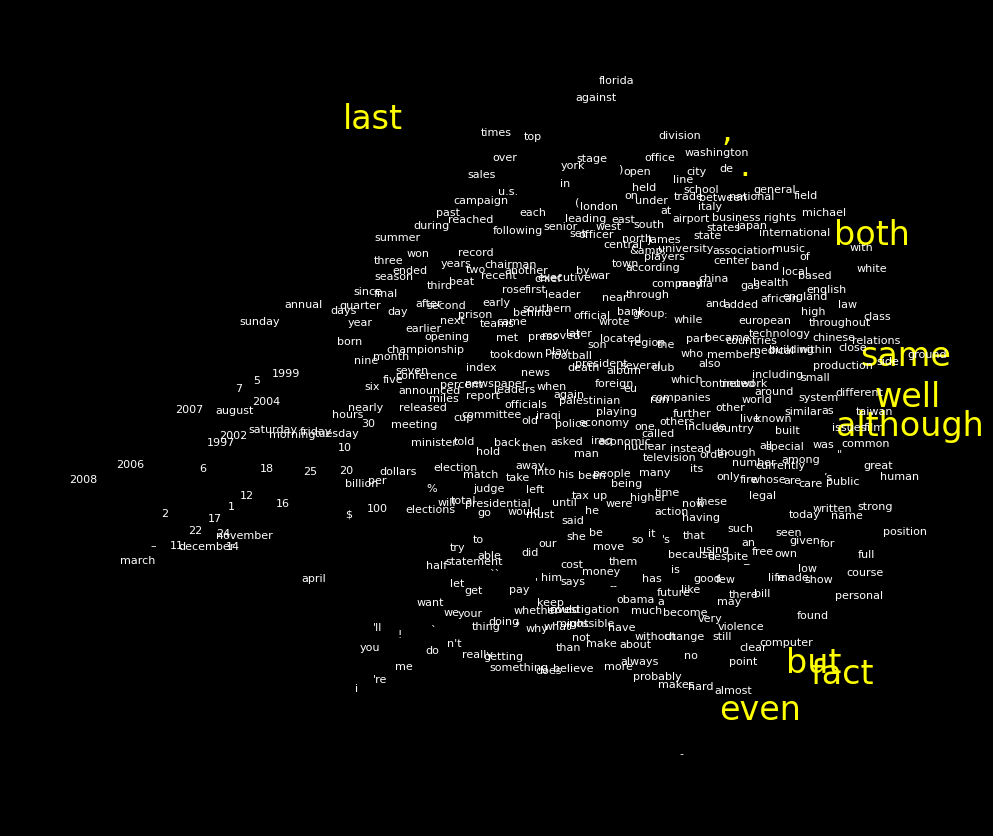

In [45]:
plot_voltage_words(voltage_map, words)